In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 1. LOAD THE DATA (Using the paths from your group's repository)
SHADOW_PATH = "shadow_hubs_residual_2019plus.csv"
NODES_PATH = "nodes_country_oil_2019plus.csv"

shadow_df = pd.read_csv(SHADOW_PATH)
nodes_df = pd.read_csv(NODES_PATH)

In [5]:
shadow_df.head()

,year,iso3,betweenness,trade_total_usd,in_deg,out_deg,prune_threshold_usd,edges_after_pruning,nodes_after_pruning,log_btw,log_vol,btw_expected,shadow_resid,shadow_rank
0,2019,COL,0.011684,6.830752e+10,45,51,0.001,8111,237,0.011616,24.947286,0.055398,-0.043782,70.0
1,2019,NLD,0.201190,2.235856e+11,107,184,0.001,8111,237,0.183313,26.133060,0.079287,0.104025,3.0
2,2019,PAN,0.004237,2.495475e+10,63,24,0.001,8111,237,0.004228,23.940330,0.035111,-0.030883,60.0
3,2019,USA,0.329463,6.010105e+11,115,181,0.001,8111,237,0.284775,27.121878,0.099209,0.185566,1.0
4,2019,AGO,0.002939,6.409265e+10,45,28,0.001,8111,237,0.002935,24.883595,0.054115,-0.051180,72.0


In [6]:
nodes_df.head()

,country_iso3,country_name,iso2,code,is_group,ofac_entities,ofac_entity_country_links
0,ABW,Aruba,AW,533,False,1,1
1,AFG,Afghanistan,AF,4,False,82,82
2,AGO,Angola,AO,24,False,11,11
3,AIA,Anguilla,AI,660,False,0,0
4,ALB,Albania,AL,8,False,8,8


In [9]:


# 2. MERGE RISK DATA
# We join the residual scores with the OFAC entity counts from the nodes file
df_analyst = pd.merge(
    shadow_df,
    nodes_df[['country_iso3', 'ofac_entities', 'country_name']],
    left_on='iso3',
    right_on='country_iso3',
    how='left'
)
df_analyst.head()

,year,iso3,betweenness,trade_total_usd,in_deg,out_deg,prune_threshold_usd,edges_after_pruning,nodes_after_pruning,log_btw,log_vol,btw_expected,shadow_resid,shadow_rank,country_iso3,ofac_entities,country_name
0,2019,COL,0.011684,6.830752e+10,45,51,0.001,8111,237,0.011616,24.947286,0.055398,-0.043782,70.0,COL,383,Colombia
1,2019,NLD,0.201190,2.235856e+11,107,184,0.001,8111,237,0.183313,26.133060,0.079287,0.104025,3.0,NLD,58,Netherlands
2,2019,PAN,0.004237,2.495475e+10,63,24,0.001,8111,237,0.004228,23.940330,0.035111,-0.030883,60.0,PAN,144,Panama
3,2019,USA,0.329463,6.010105e+11,115,181,0.001,8111,237,0.284775,27.121878,0.099209,0.185566,1.0,USA,75,USA
4,2019,AGO,0.002939,6.409265e+10,45,28,0.001,8111,237,0.002935,24.883595,0.054115,-0.051180,72.0,AGO,11,Angola


In [17]:


# 3. ANALYSIS: Identify "The Jumpers" (Pre- vs. Post-2022 Sanctions)
# We compare the shadow residual from 2021 to 2024
pivot = df_analyst.pivot(index='iso3', columns='year', values='shadow_resid').fillna(0)
pivot['shadow_growth'] = pivot[2024] - pivot[2021]
pivot.head()

year,2019,2020,2021,2022,2023,2024,shadow_growth
iso3,,,,,,,
AGO,-0.051180,-0.048406,-0.042576,-0.035469,-0.040525,-0.022223,0.020354
ARE,-0.002213,-0.023209,-0.006991,-0.013115,-0.012060,0.000000,0.006991
ARG,0.006205,0.015981,0.007327,-0.007522,-0.000406,-0.002147,-0.009474
AUS,-0.025945,-0.030301,-0.024727,-0.036636,-0.026862,-0.022713,0.002014
AUT,-0.023108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
# Create a lookup dictionary for ISO3 to Country Name
name_lookup = df_analyst.set_index('iso3')['country_name'].to_dict()

print("\n--- Top 10 Emerging Shadow Hubs (Post-2022 Growth) ---")
# Reset index to turn ISO3 into a column, then map the name
emerging_results = emerging_hubs[['shadow_growth']].copy()
emerging_results['country_name'] = emerging_results.index.map(name_lookup)

# Reorder columns for better readability
print(emerging_results[['country_name', 'shadow_growth']])


--- Top 10 Emerging Shadow Hubs (Post-2022 Growth) ---
year    country_name  shadow_growth
iso3                               
ESP            Spain       0.094124
ITA            Italy       0.046326
BEL          Belgium       0.033717
KOR    Rep. of Korea       0.033595
GBR   United Kingdom       0.032156
GRC           Greece       0.024308
COL         Colombia       0.024080
AGO           Angola       0.020354
SAU     Saudi Arabia       0.016809
FRA           France       0.016049


In [13]:

# Top 10 countries that became significantly more "Shadow-like" after 2022
emerging_hubs = pivot.sort_values('shadow_growth', ascending=False).head(10)
emerging_hubs

year,2019,2020,2021,2022,2023,2024,shadow_growth
iso3,,,,,,,
ESP,0.086469,0.003995,-0.026427,-0.006991,-0.007603,0.067697,0.094124
ITA,-0.034087,-0.045550,-0.034011,-0.030454,-0.003869,0.012315,0.046326
BEL,-0.044934,NaN,-0.035711,-0.040139,-0.024177,-0.001993,0.033717
KOR,0.004803,-0.033641,-0.029695,-0.014237,-0.001645,0.003899,0.033595
GBR,0.015665,0.001730,-0.028385,-0.015588,-0.032341,0.003771,0.032156
GRC,-0.014362,-0.037892,-0.024728,-0.009286,-0.022631,-0.000420,0.024308
COL,-0.043782,-0.033186,-0.039096,-0.037652,-0.049242,-0.015016,0.024080
AGO,-0.051180,-0.048406,-0.042576,-0.035469,-0.040525,-0.022223,0.020354
SAU,NaN,NaN,-0.071376,NaN,NaN,-0.054567,0.016809


--- 1. OFFICIAL TOP 10 SHADOW HUBS (2024) ---
country_name iso3  shadow_resid  ofac_entities
         USA  USA      0.224350             75
       Spain  ESP      0.067697             48
 Netherlands  NLD      0.057659             58
   Singapore  SGP      0.054936            110
       India  IND      0.031328            140
  Uzbekistan  UZB      0.029023             25
     Türkiye  TUR      0.023758            350
  Mozambique  MOZ      0.017156              8
     Georgia  GEO      0.015724             15
       Kenya  KEN      0.015455             19




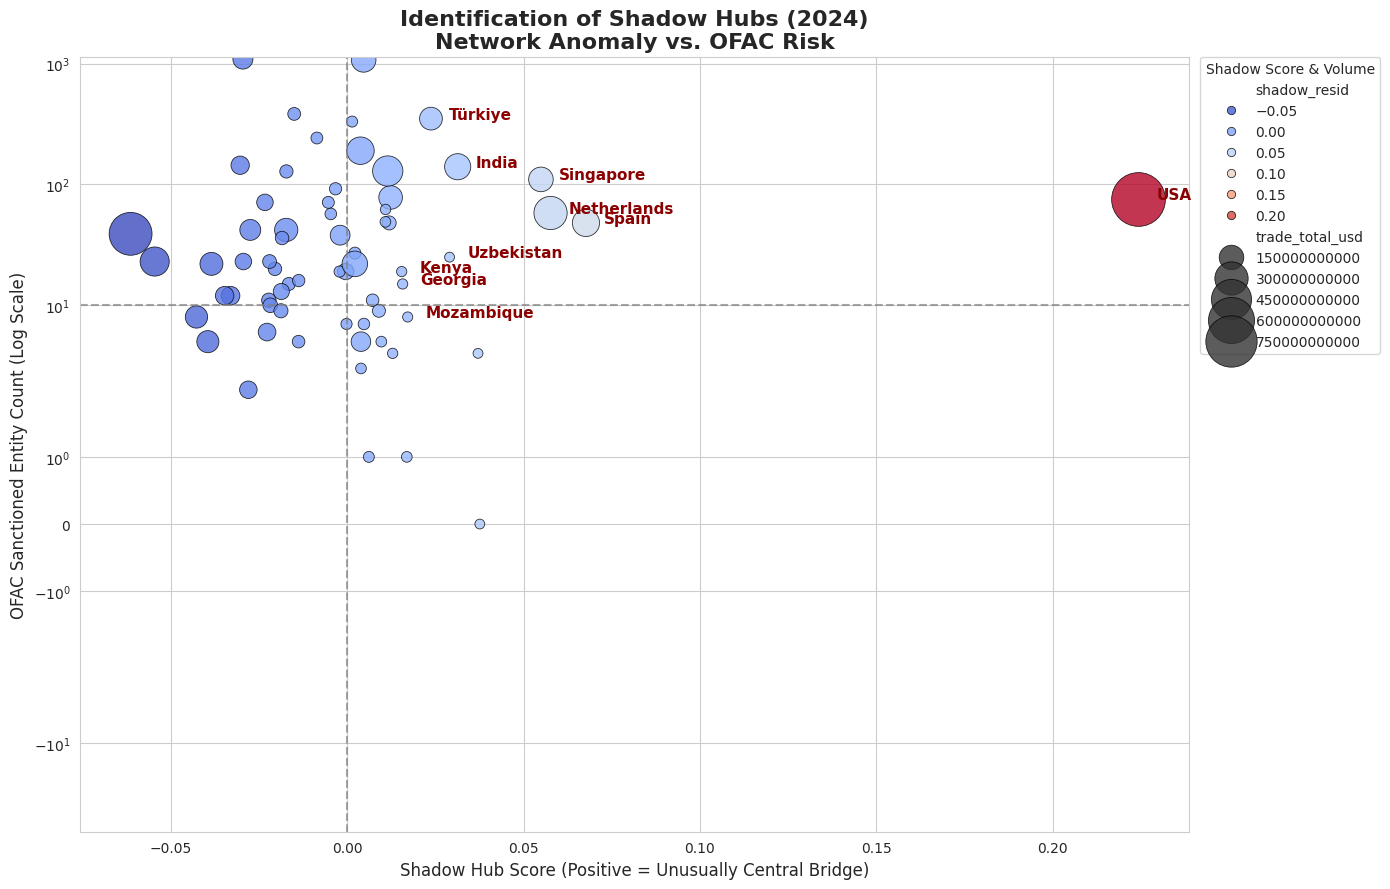

--- 3. CLUSTERING COEFFICIENTS FOR THE TOP 10 (2024) ---
country_name  shadow_resid  clustering_weighted
         USA      0.224350             0.200772
       Spain      0.067697             0.242480
 Netherlands      0.057659             0.200610
   Singapore      0.054936             0.182441
       India      0.031328             0.212388
  Uzbekistan      0.029023             0.422725
     Türkiye      0.023758             0.188349
  Mozambique      0.017156             0.435597
     Georgia      0.015724             0.452402
       Kenya      0.015455             0.311513


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# ==========================================
# CORE LOGIC: Define the Top 10 ONCE
# ==========================================
# 1. Filter for the latest data
latest_year = df_analyst['year'].max()
latest_data = df_analyst[df_analyst['year'] == latest_year].copy()

# 2. Filter for actual shadow candidates: Positive residual AND > 5 OFAC entities
shadow_candidates = latest_data[
    (latest_data['shadow_resid'] > 0) &
    (latest_data['ofac_entities'] > 5)
]

# 3. Sort by the most extreme anomalies (Network math) to get the Top 10
# We define this ONCE, and use it for all 3 outputs
top_10_shadows = shadow_candidates.sort_values(by='shadow_resid', ascending=False).head(10)

# Extract just the ISO3 codes of these 10 targets for the clustering math later
suspect_iso_list = top_10_shadows['iso3'].tolist()

# ==========================================
# OUTPUT 1: Print the Top 10 Shadow Hubs
# ==========================================
print(f"--- 1. OFFICIAL TOP 10 SHADOW HUBS ({latest_year}) ---")
# Using .to_string(index=False) makes the printout look much cleaner
print(top_10_shadows[['country_name', 'iso3', 'shadow_resid', 'ofac_entities']].to_string(index=False))
print("\n")

# ==========================================
# OUTPUT 2: Visualize these Exact 10 Hubs
# ==========================================
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

# Create the scatter plot (Plotting all data so the context is visible)
scatter = sns.scatterplot(
    data=latest_data,
    x='shadow_resid',
    y='ofac_entities',
    size='trade_total_usd',
    hue='shadow_resid',
    palette='coolwarm',
    sizes=(50, 1500),
    alpha=0.8,
    edgecolor='black'
)

# Use a Symmetric Log Scale for the Y-Axis
plt.yscale('symlog')

# Draw "Quadrant" Reference Lines
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=10, color='gray', linestyle='--', alpha=0.7)

# Apply the labels ONLY to the exact Top 10 we defined above
for i, row in top_10_shadows.iterrows():
    plt.text(
        row['shadow_resid'] + 0.005,
        row['ofac_entities'],
        row['country_name'],
        fontsize=11,
        fontweight='bold',
        color='darkred'
    )

# Final Formatting
plt.title(f"Identification of Shadow Hubs ({latest_year})\nNetwork Anomaly vs. OFAC Risk", fontsize=16, fontweight='bold')
plt.xlabel("Shadow Hub Score (Positive = Unusually Central Bridge)", fontsize=12)
plt.ylabel("OFAC Sanctioned Entity Count (Log Scale)", fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., title="Shadow Score & Volume")
plt.tight_layout()
plt.show()

# ==========================================
# OUTPUT 3: Clustering Coefficients for the Top 10
# ==========================================
print(f"--- 3. CLUSTERING COEFFICIENTS FOR THE TOP 10 ({latest_year}) ---")
try:
    # Load the edges for the latest year
    # NOTE: Ensure this path matches the location of your edges file!
    edges = pd.read_csv("edges_country_oil_2019plus.csv")
    edges_latest = edges[edges['year'] == latest_year].copy()

    # We need a positive weight for the weighted clustering
    edges_latest['log_weight'] = np.log1p(edges_latest['trade_value_usd'])

    # Build the Global Graph
    G_weighted = nx.from_pandas_edgelist(
        edges_latest,
        source='exporter_iso3',
        target='importer_iso3',
        edge_attr='log_weight',
        create_using=nx.Graph()
    )

    # Apply Clustering ONLY to the exact 10 Suspects we found in Step 1
    weighted_cc = nx.clustering(G_weighted, nodes=suspect_iso_list, weight='log_weight')

    # Map the results back to a copy of our top 10 dataframe
    top_10_clustering = top_10_shadows.copy()
    top_10_clustering['clustering_weighted'] = top_10_clustering['iso3'].map(weighted_cc)

    print(top_10_clustering[['country_name', 'shadow_resid', 'clustering_weighted']].to_string(index=False))

except FileNotFoundError:
    print("Error: Could not find 'edges_country_oil_2019plus.csv' to calculate clustering.")
    print("Make sure the file path is correct!")